In [2]:
import numpy as np
from pathlib import Path


#! VOGLIO MORIRE
data = np.load( "../solutions/transient.npy").T

data.shape

(3, 100)

<ErrorbarContainer object of 3 artists>

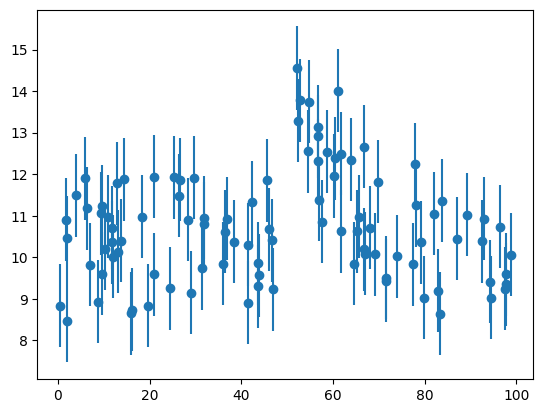

In [3]:
import matplotlib.pyplot as plt

plt.errorbar(data[0], data[1], data[2], marker="o", linestyle="none")

(0.006737947007218007, 0.1918836414306194)


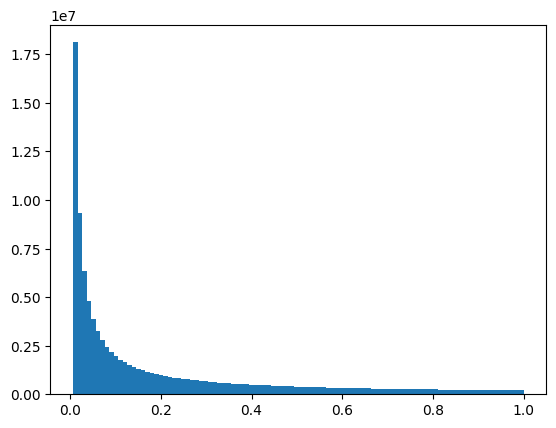

In [ ]:

from scipy.stats import uniform, expon

a = uniform(loc=-5, scale=5)
dataset = np.exp(a.rvs(int(1e8)))
plt.hist( dataset, bins = 100)

count , edges = np.histogram( dataset , bins = 100)

x_point = [edges[i] + edges[i+1] for i in range(len(edges)-1)]

param_priors = print(expon.fit(dataset))

A = 0
tau = 5

if param_priors is None:
    param_priors = expon.fit(dataset)

if param_priors[0] is not None:
    A = param_priors[0]
if param_priors[1] is not None:
    tau = param_priors[1]


In [18]:
from scipy.stats import expon, norm
def model( x , t0 , A , l , b):
    return b + A*expon.pdf(x , loc = t0 , scale = 1/l)

def likelyhood( x , y , y_err , model, params):
    return np.prod(norm.pdf(y - model(x , *params) , loc = 0 , scale = y_err))

def prior(x):
    if param_priors is None:
        raise ValueError("param_priors must be set before calling prior()")
    return (1 / 100) * (1 / 50) * expon.pdf(x, loc=param_priors[0], scale=param_priors[1]) * (1 / 50)

def Posterior( params , x , y , y_err):
    return likelyhood(x, y, y_err, model, params) * prior(params[2])

def logPosterior( params , x , y , y_err):
    if not np.isfinite(np.log(Posterior(params, x , y , y_err))) or np.isnan(np.log(Posterior(params, x , y , y_err))):
        return -np.inf
    return np.log(Posterior(params, x , y , y_err))


In [19]:
import emcee

ndim = 4
nwalkers = 10
nsteps = int(1e6)

starting_guesses = np.random.random((nwalkers, ndim))



sampler = emcee.EnsembleSampler(nwalkers, ndim, Posterior , args=[data[0] , data[1] , data[2]])

sampler.run_mcmc(starting_guesses, nsteps)

ValueError: Probability function returned NaN